In [59]:
import os
import re
import chess.pgn
import pandas as pd
import numpy as np
from pathlib import Path
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt

In [49]:

# 1. Get the directory where your current notebook is running
# In Jupyter notebooks, os.getcwd() returns the notebook's directory
current_notebook_dir = Path(os.getcwd())
print(f"Current workspace location: {current_notebook_dir}")

# 2. Navigate relatively: up 2 levels (elias_sandbox -> workspace -> root), then down into data
DATA_DIR = current_notebook_dir.parents[1] / "data" / "elias_data"
PGN_FILE_PATH = DATA_DIR / "lichess_db_standard_rated_2017-05.pgn"

print(f"Resolved Data Directory Path: {DATA_DIR.resolve()}")
print(f"Targeting PGN File at: {PGN_FILE_PATH.resolve()}")

# 3. Explicit programmatic check to prevent silent pipeline failures
if not PGN_FILE_PATH.exists():
    print("\n[!] Debugging Check Failed:")
    print(f"The directory '{DATA_DIR}' exists: {DATA_DIR.exists()}")
    print("Files currently visible inside the target data directory:")
    if DATA_DIR.exists():
        for f in DATA_DIR.iterdir():
            print(f" - {f.name}")
    else:
         print(" - Cannot list files because the directory path itself is invalid.")
    raise FileNotFoundError(f"Python explicitly cannot find the file at: {PGN_FILE_PATH.resolve()}")
else:
    print("\n[+] Success! File targeted cleanly. Safe to initiate data streaming layer.")
def stream_pgn_games(file_path, max_games=None):
    """Sequence generator to stream games sequentially from disk."""
    games_count = 0
    with open(file_path, "r", encoding="utf-8") as pgn_file:
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            yield game
            games_count += 1
            if max_games and games_count >= max_games:
                break

def extract_all_features(game):
    """Dynamically extracts all PGN metadata tags and sequence telemetry."""
    # Capture all headers dynamically as a dictionary
    features_dict = dict(game.headers)
    
    # Clean up standard numerical fields for modeling safety
    for numeric_field in ["WhiteElo", "BlackElo", "WhiteRatingDiff", "BlackRatingDiff"]:
        if numeric_field in features_dict:
            val = features_dict[numeric_field].replace("+", "").replace("-", "-")
            try:
                features_dict[numeric_field] = int(val)
            except ValueError:
                features_dict[numeric_field] = None # Handle erratic string corruptions
                
    # Parse sequence dynamics
    moves = []
    clocks = []
    
    node = game
    while not node.is_end():
        next_node = node.next()
        moves.append(str(next_node.move))
        
        # Extract Lichess clock comment [%clk h:mm:ss]
        comment = next_node.comment
        clk_match = [text for text in comment.split() if "%clk" in text]
        clocks.append(comment if clk_match else None)
        node = next_node
        
    # Append sequential features to the dictionary
    features_dict["total_moves"] = len(moves)
    features_dict["moves_sequence"] = moves
    features_dict["clocks_raw_sequence"] = clocks
    
    return features_dict

Current workspace location: c:\Masters\ALM\AppML_FinalProject\root\workspace\elias_sandbox
Resolved Data Directory Path: C:\Masters\ALM\AppML_FinalProject\root\data\elias_data
Targeting PGN File at: C:\Masters\ALM\AppML_FinalProject\root\data\elias_data\lichess_db_standard_rated_2017-05.pgn

[+] Success! File targeted cleanly. Safe to initiate data streaming layer.


In [50]:
# --- Simple Data Ingestion Layer ---
all_games = []
MAX_GAMES_TO_PROCESS = 100000 

print(f"Beginning ingestion of {MAX_GAMES_TO_PROCESS} games into memory...")

# Define where your processed file lives
pickle_path = DATA_DIR / "chess_data_full-2017-05.pkl"

if pickle_path.exists():
    print(f"[+] Pickle file found at {pickle_path}. Loading data into memory...")
    df = pd.read_pickle(pickle_path)
    print(f"Data loaded successfully. Total games: {len(df)}")
    
elif PGN_FILE_PATH.exists():
    print(f"[!] No pickle found. Starting full ingestion from PGN...")
    all_games = []
    MAX_GAMES_TO_PROCESS = 100000 
    
    for i, game in enumerate(stream_pgn_games(PGN_FILE_PATH, max_games=MAX_GAMES_TO_PROCESS)):
        game_features = extract_all_features(game)
        all_games.append(game_features)
        
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1} games...")

    # Convert to DataFrame
    df = pd.DataFrame(all_games)
    
    # Save for next time
    df.to_pickle(pickle_path)
    print(f"Ingestion complete. Saved to {pickle_path}. Total games: {len(df)}")
    
else:
    print(f"Error: PGN file not found at {PGN_FILE_PATH}")

Beginning ingestion of 100000 games into memory...
[+] Pickle file found at c:\Masters\ALM\AppML_FinalProject\root\data\elias_data\chess_data_full-2017-05.pkl. Loading data into memory...
Data loaded successfully. Total games: 100000


### 1. Why We Batched and Injected into Parquet

- When engineering data pipelines for machine learning, the goal is to prevent the system's ability to read and write data from being slower than its ability to process that data, a scenario known as an I/O bottleneck.  Memory Management: Loading a massive PGN file directly into memory will quickly exhaust your RAM and crash your environment. By streaming the data and writing it in chunks, you maintain a flat $O(1)$ memory complexity, allowing you to process infinitely large datasets.

- High-Performance Storage: Apache Parquet is a columnar storage format that is highly efficient for tabular data and offers excellent compression and predicate pushdown. When architecting high-performance computing pipelines, reading contiguous columns allows thousands of GPU threads to read in lock-step, keeping the GPU fed and preventing CPU-bound preprocessing from stalling the pipeline

. The Setup: __init__(self)
This method runs when you first create the vocabulary object. It sets up the empty dictionaries and the starting counters.

self.move_to_id: The dictionary that converts text to numbers (e.g., "e4" -> 2).

self.id_to_move: The reverse dictionary that converts numbers back to text (e.g., 2 -> "e4"). You use this later if you want the model to generate text moves.

The Special Tokens:

"<PAD>": 0: Neural networks need sequences of the exact same length (e.g., 50 moves). If a game ends in 20 moves, you pad the rest of the sequence with 0s.

"<UNK>": 1: Stands for "Unknown". If your model later sees a crazy move in a new game that wasn't in your training data, it translates it to 1 instead of crashing your program.

self.move_idx = 2: This is the counter. Since 0 and 1 are taken, the very first real chess move your loop sees will be assigned the ID 2.

The ECO Setup: It does the exact same thing for the Opening codes. Notice there is no <PAD> for ECO codes, because a game only ever has one ECO code, so we don't need to pad sequences of them!

2. Learning New Words: add_move and add_eco
These methods are called during your data ingestion loop (when you do for move in row['moves_sequence']:).

Python
def add_move(self, move):
    if move not in self.move_to_id:             # "Have I seen 'Nf3' before?"
        self.move_to_id[move] = self.move_idx   # "No. Add 'Nf3' to the dict as ID 2."
        self.id_to_move[self.move_idx] = move   # "Also add 2 -> 'Nf3' to the reverse dict."
        self.move_idx += 1                      # "Increase counter to 3 for the next new move."
As it reads thousands of games, this dictionary grows until it has assigned a unique ID to practically every possible chess move.

3. The Translation: encode_moves and encode_eco
These methods are used inside your __getitem__ function to actually convert the data right before feeding it to the PyTorch DataLoader.

Python
def encode_moves(self, move_sequence):
    return [self.move_to_id.get(move, self.move_to_id["<UNK>"]) for move in move_sequence]
This is a Python list comprehension. Let's say you pass it the sequence ["e4", "c5", "Ke2"].

It looks up "e4". Let's say it finds it as ID 2.

It looks up "c5". Let's say it finds it as ID 3.

It looks up "Ke2" (the Bongcloud opening). Let's say this move was never played in your training data.

Because of the .get(move, self.move_to_id["<UNK>"]) logic, instead of throwing a KeyError, it safely returns 1 (the ID for <UNK>).

Final output: [2, 3, 1]

Summary
Without this class, your neural network would throw a TypeError the moment you tried to pass it a chessboard string. This class systematically converts the game of chess into the mathematical language your LSTM layers require

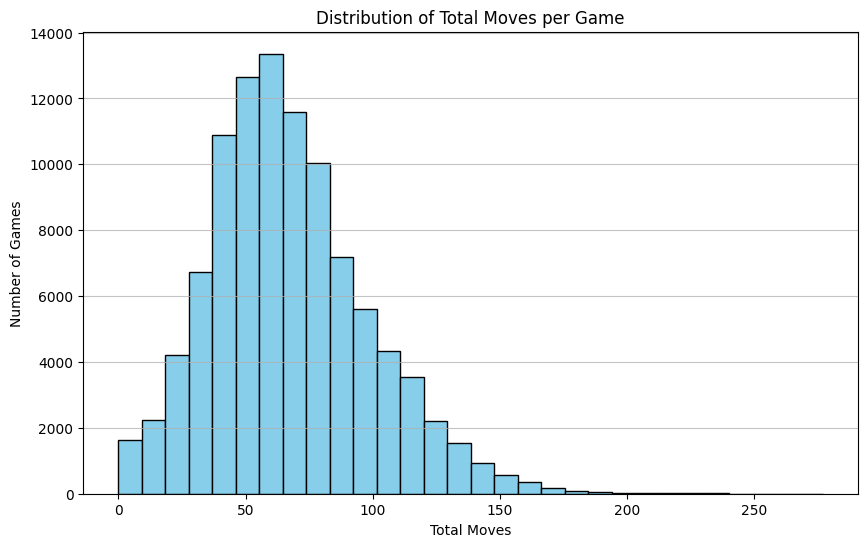

95% of games finish in 124.0 moves or less.
99% of games finish in 152.0 moves or less.


In [61]:
# Plot histogram over total moves distribution
plt.figure(figsize=(10, 6))
plt.hist(df["total_moves"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Total Moves per Game")
plt.xlabel("Total Moves")
plt.ylabel("Number of Games")
plt.grid(axis='y', alpha=0.75)
plt.show()

# Calculate the 95th and 99th percentiles
p95 = df['total_moves'].quantile(0.95)
p99 = df['total_moves'].quantile(0.99)

print(f"95% of games finish in {p95} moves or less.")
print(f"99% of games finish in {p99} moves or less.")

In [ ]:
# 1. Build a simple Vocabulary to map string moves to Integer Tokens
class ChessVocabulary:
    def __init__(self):
        self.move_to_id = {"<PAD>": 0, "<UNK>": 1}
        self.id_to_move = {0: "<PAD>", 1: "<UNK>"}
        self.move_idx = 2
        
        # New dictionary for ECO codes
        self.eco_to_id = {"<UNK>": 0}
        self.eco_idx = 1
        
    def add_move(self, move):
        if move not in self.move_to_id:
            self.move_to_id[move] = self.move_idx
            self.id_to_move[self.move_idx] = move
            self.move_idx += 1
            
    def add_eco(self, eco):
        if eco not in self.eco_to_id:
            self.eco_to_id[eco] = self.eco_idx
            self.eco_idx += 1
            
    def encode_moves(self, move_sequence):
        return [self.move_to_id.get(move, self.move_to_id["<UNK>"]) for move in move_sequence]
    
    def encode_eco(self, eco):
        return self.eco_to_id.get(eco, 0)

def parse_clock_to_seconds(clk_str):
    """Extracts the time from '[%clk h:mm:ss]' and converts to total seconds."""
    if not clk_str:
        return 0.0
    match = re.search(r'\[%clk\s+([\d:]+)\]', str(clk_str))
    if match:
        parts = match.group(1).split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + float(parts[1])
    return 0.0

def parse_time_control(tc_str):
    """Parses '300+0' into (300, 0). Returns (None, None) if invalid."""
    if not tc_str or tc_str == '-' or '+' not in str(tc_str):
        return None, None
    try:
        base, inc = str(tc_str).split('+')
        return float(base), float(inc)
    except ValueError:
        return None, None

class ChessDataset(Dataset):
    def __init__(self, df, vocab):
        self.vocab = vocab
        self.data = []
        
        # We iterate directly over the DataFrame
        for _, row in df.iterrows():
            # 1. Populate vocabulary (Moves and ECO)
            for move in row['moves_sequence']:
                self.vocab.add_move(move)
            
            eco = row.get('ECO', 'A00')
            self.vocab.add_eco(eco)
            
            # Inside ChessDataset.__init__

            # Extract the time control from the dataframe row
            tc_str = row.get('TimeControl', '300+0')
            base_time, increment = parse_time_control(tc_str)

            # Fallback in case of weird data
            if base_time is None or base_time <= 0:
                base_time = 300.0 

            raw_clocks = row.get('clocks_raw_sequence', [])
            numeric_clocks = [parse_clock_to_seconds(c) for c in raw_clocks]

            # DYNAMIC NORMALIZATION
            normalized_clocks = [c / base_time for c in numeric_clocks]
            # 3. Define target
            label = 1.0 if int(row['WhiteElo']) > 1800 else 0.0
            
            # Save the ID
            eco_id = self.vocab.encode_eco(eco)
            
            self.data.append((row['moves_sequence'], normalized_clocks, eco_id, label))
                
    def __len__(self):
        # This tells the DataLoader how many items exist
        return len(self.data)

    def __getitem__(self, idx):
        # This tells the DataLoader how to fetch one specific item
        moves, clocks, eco_id, label = self.data[idx]
        
        tokenized_moves = torch.tensor(self.vocab.encode_moves(moves), dtype=torch.long)
        
        # Pad/Truncate clocks to match moves length
        if len(clocks) < len(moves):
            clocks.extend([0.0] * (len(moves) - len(clocks)))
        elif len(clocks) > len(moves):
            clocks = clocks[:len(moves)]
            
        clock_tensor = torch.tensor(clocks, dtype=torch.float32)
        
        # Return the 4 variables
        return tokenized_moves, clock_tensor, torch.tensor(eco_id, dtype=torch.long), torch.tensor(label, dtype=torch.float32)

# ==========================================
# FIXED: NEW DUAL MODAL COLLATE FUNCTION
# ==========================================
def dual_modal_collate_fn(batch, max_len=150): #max_len is max length of game, was 50 before
    move_seqs = [item[0][:max_len] for item in batch]
    clock_seqs = [item[1][:max_len] for item in batch]
    eco_ids = torch.tensor([item[2] for item in batch], dtype=torch.long) # NEW
    labels = torch.tensor([item[3] for item in batch], dtype=torch.float32)
    
    padded_moves = pad_sequence(move_seqs, batch_first=True, padding_value=0)
    padded_clocks = pad_sequence(clock_seqs, batch_first=True, padding_value=0.0)
    
    return padded_moves, padded_clocks, eco_ids, labels


# ==========================================
# DATA LOADING
# ==========================================
# 1. Use the robust relative path resolution we established earlier
current_notebook_dir = Path(os.getcwd())
DATA_DIR = current_notebook_dir.parents[1] / "data" / "elias_data"

# Assuming you have your 'df' from the ingestion step:
# df = pd.DataFrame(all_games) # (If you just ran the loop)
# OR if you loaded it from your saved file:
# df = pd.read_pickle(DATA_DIR / "chess_data_full.pkl")

vocab = ChessVocabulary()
# Pass the DataFrame 'df' directly here
chess_dataset = ChessDataset(df, vocab)

print(f"Dataset successfully loaded with {len(chess_dataset)} games.")
if len(chess_dataset) == 0:
    raise ValueError("The dataset is empty! Check if the `.dropna()` method filtered out all your rows.")

# Utilize multiple CPU workers for parallel loading and pin_memory for faster GPU transfer
dataloader = DataLoader(
    chess_dataset, 
    batch_size=128, 
    shuffle=True, 
    collate_fn=dual_modal_collate_fn, # FIXED: Using the new collate function
    num_workers=0,        
    pin_memory=True       
)

# ==========================================
# FIXED: UNPACKING 4 VARIABLES
# ==========================================
print(f"Vocabulary size: {len(vocab.move_to_id)} unique tokens.")
sample_moves, sample_clocks, sample_eco_ids, sample_labels = next(iter(dataloader))
print(f"Padded Moves Shape: {sample_moves.shape}") 
print(f"Padded Clocks Shape: {sample_clocks.shape}")
print(f"ECO IDs Shape: {sample_eco_ids.shape}")
print(f"Labels Shape: {sample_labels.shape}")

#Show 1 set of moves, clocks, and label
print("\nSample Moves (token IDs):", sample_moves[0].tolist())
print("Sample Clocks (normalized seconds):", sample_clocks[0].tolist())
print("Sample ECO IDs:", sample_eco_ids[0].item())
print("Sample Label (1=WhiteElo>1800, 0=WhiteElo<=1800):", sample_labels[0].item())

Dataset successfully loaded with 100000 games.
Vocabulary size: 1910 unique tokens.
Padded Moves Shape: torch.Size([128, 100])
Padded Clocks Shape: torch.Size([128, 100])
ECO IDs Shape: torch.Size([128])
Labels Shape: torch.Size([128])

Sample Moves (token IDs): [2, 96, 8, 163, 107, 143, 404, 182, 157, 370, 28, 11, 6, 800, 26, 738, 110, 502, 392, 55, 169, 556, 450, 185, 653, 336, 69, 467, 599, 1013, 567, 1009, 599, 1013, 567, 1349, 599, 43, 44, 553, 458, 331, 1713, 1776, 372, 190, 1258, 559, 1413, 472, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample Clocks (normalized seconds): [2.0, 2.0, 1.993333339691162, 1.9900000095367432, 1.9833333492279053, 1.8899999856948853, 1.7300000190734863, 1.8700000047683716, 1.7066667079925537, 1.846666693687439, 1.6966667175292969, 1.7899999618530273, 1.6799999475479126, 1.7833333015441895, 1.6699999570846558, 1.7799999713897705, 1.666666626930236

c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Decoding your Tensor Shapes
Let's translate exactly what those shapes mean in plain English:

1. Padded Moves: [128, 50]

Think of this as an Excel spreadsheet.

It has 128 rows (One row for every game in this batch).

It has 50 columns (One column for every move). Why 50? Because in your dual_modal_collate_fn, you wrote max_len=50. You are forcing every game to be exactly 50 moves long by either cutting off the end of long games or padding short games with zeros.

2. Padded Clocks: [128, 50]

Exactly the same as above. 128 games (rows), and 50 clock times (columns) corresponding perfectly to the 50 moves.

3. ECO IDs: [128]

This is a 1-dimensional list.

It has 128 items in it. Each item is a single integer representing the Opening Code for that specific game. Because a game only has one opening, it doesn't need 50 columns.

4. Labels: [128]

Another 1-dimensional list of 128 items.

Each item is either a 1.0 (High Elo) or 0.0 (Low Elo) for that specific game.

In [52]:
def check_class_balance(dataset):
    """Calculates and prints the class distribution of the PyTorch dataset."""
    print("--- Dataset Class Balance ---")
    
    # FIX: Unpack 4 values instead of 3 (moves, clocks, eco_id, label)
    # The 4th item is the label, so we use 3 underscores to ignore the first 3 items
    labels = [label for _, _, _, label in dataset.data]
    
    total_samples = len(labels)
    
    if total_samples == 0:
        print("Dataset is empty!")
        return
        
    class_1_count = sum(labels)
    class_0_count = total_samples - class_1_count
    
    print(f"Total Games: {total_samples}")
    print(f"Class 1 (High Elo): {class_1_count} games ({class_1_count / total_samples * 100:.2f}%)")
    print(f"Class 0 (Low Elo):  {class_0_count} games ({class_0_count / total_samples * 100:.2f}%)")
    
    # Calculate baseline accuracy
    majority_class_pct = max(class_1_count, class_0_count) / total_samples * 100
    print(f"\n[!] Baseline to beat: A model guessing the majority class achieves {majority_class_pct:.2f}% accuracy.")

# Run the check on your instantiated dataset
check_class_balance(chess_dataset)

--- Dataset Class Balance ---
Total Games: 100000
Class 1 (High Elo): 28899.0 games (28.90%)
Class 0 (Low Elo):  71101.0 games (71.10%)

[!] Baseline to beat: A model guessing the majority class achieves 71.10% accuracy.


In [53]:
import torch.nn as nn
import torch

# ==========================================
# 1. UPGRADED ARCHITECTURE (Bidirectional)
# ==========================================
class DualModalChessLSTM(nn.Module):
    # Reduced hidden_dim to 64 to prevent memorization
    def __init__(self, vocab_size, num_eco_codes, embedding_dim=64, hidden_dim=64):
        super(DualModalChessLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.eco_embedding = nn.Embedding(num_eco_codes, 16)
        
        # UPGRADE 1: Bidirectional = True
        self.lstm = nn.LSTM(
            input_size=embedding_dim + 1, 
            hidden_size=hidden_dim, 
            batch_first=True, 
            num_layers=2, 
            dropout=0.5, # Increased dropout for safety
            bidirectional=True 
        )
        
        # UPGRADE 2: FC layer must accept double the hidden_dim 
        # because the LSTM now outputs a forward AND a backward summary
        self.fc = nn.Linear((hidden_dim * 2) + 16, 1)
        
    def forward(self, moves, clocks, eco_ids):
        # A. Sequence Logic
        embedded_moves = self.embedding(moves)
        clocks_expanded = clocks.unsqueeze(-1)
        fused_sequence = torch.cat((embedded_moves, clocks_expanded), dim=2)
        
        # B. Pass through Bidirectional LSTM
        _, (h_n, _) = self.lstm(fused_sequence)
        
        # UPGRADE 3: Grab BOTH the forward and backward final states from the top layer
        # h_n[-2] is the forward direction, h_n[-1] is the backward direction
        final_forward = h_n[-2, :, :]
        final_backward = h_n[-1, :, :]
        final_state = torch.cat((final_forward, final_backward), dim=1) # [Batch, Hidden*2]
        
        # C. Fusion
        embedded_eco = self.eco_embedding(eco_ids) 
        combined_features = torch.cat((final_state, embedded_eco), dim=1)
        
        # D. Predict
        logits = self.fc(combined_features)
        return logits.squeeze(1)


# ==========================================
# 2. UPGRADED INITIALIZATION & WEIGHTS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

# Initialize model
vocab_size = len(vocab.move_to_id)
num_eco_codes = len(vocab.eco_to_id)
model = DualModalChessLSTM(
    vocab_size=vocab_size, 
    num_eco_codes=num_eco_codes,
    hidden_dim=64 # Enforce the smaller brain size
).to(device)

# UPGRADE 4: Re-apply the Class Weights (63% vs 36% imbalance)
weight_ratio = 6351.0 / 3649.0
pos_weight_tensor = torch.tensor([weight_ratio]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# UPGRADE 5: AdamW instead of Adam
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# UPGRADE 6: The Learning Rate Scheduler
# This will automatically drop the learning rate if the model gets "stuck"
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

print("Model architecture compiled successfully with Bidirectional and AdamW upgrades.")

Compute Device: cpu
Model architecture compiled successfully with Bidirectional and AdamW upgrades.


In [54]:
# # --- Training Loop ---
# epochs = 3
# print("Initiating Training...")

# for epoch in range(epochs):
#     model.train() # Set model to training mode
#     total_loss = 0
#     correct_predictions = 0
#     total_samples = 0
    
#     for batch_idx, (moves, labels) in enumerate(dataloader):
#         # Move tensors to the active compute device (CPU or GPU)
#         moves = moves.to(device)
#         labels = labels.to(device)
        
#         # 1. Forward Pass: Make predictions
#         optimizer.zero_grad() # Clear old gradients
#         logits = model(moves)
        
#         # 2. Compute Loss
#         loss = criterion(logits, labels)
        
#         # 3. Backward Pass: Calculate gradients
#         loss.backward()
        
#         # 4. Optimization Step: Update weights
#         optimizer.step()
        
#         # --- Tracking Metrics ---
#         total_loss += loss.item()
        
#         # Convert raw logits to binary predictions (0 or 1) using a Sigmoid threshold of 0.5
#         probabilities = torch.sigmoid(logits)
#         predictions = (probabilities > 0.5).float()
        
#         correct_predictions += (predictions == labels).sum().item()
#         total_samples += labels.size(0)
        
#         # Print progress every 10 batches
#         if batch_idx % 10 == 0:
#             print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx}] | Loss: {loss.item():.4f}")
            
#     # Epoch Summary
#     epoch_loss = total_loss / len(dataloader)
#     epoch_acc = (correct_predictions / total_samples) * 100
#     print(f"--- Epoch {epoch+1} Summary | Avg Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}% ---\n")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

# ==========================================
# 1. TRUNCATION & DATA SPLIT
# ==========================================
def dual_modal_collate_fn(batch, max_len=150):
    """Pads moves/clocks, and collects ECO IDs and labels."""
    # item[0] = moves, item[1] = clocks, item[2] = eco_id, item[3] = label
    move_seqs = [item[0][:max_len] for item in batch]
    clock_seqs = [item[1][:max_len] for item in batch]
    
    # Correctly index the new 4-item tuple
    eco_ids = torch.tensor([item[2] for item in batch], dtype=torch.long) 
    labels = torch.tensor([item[3] for item in batch], dtype=torch.float32)
    
    padded_moves = pad_sequence(move_seqs, batch_first=True, padding_value=0)
    padded_clocks = pad_sequence(clock_seqs, batch_first=True, padding_value=0.0)
    
    return padded_moves, padded_clocks, eco_ids, labels

# Calculate split sizes (80% Train, 20% Validation)
total_size = len(chess_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Split the dataset randomly
train_dataset, val_dataset = random_split(chess_dataset, [train_size, val_size])

# Create TWO DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True, 
    collate_fn=dual_modal_collate_fn, num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=128, shuffle=False, 
    collate_fn=dual_modal_collate_fn, num_workers=0, pin_memory=True
)

print(f"Training on {train_size} games. Validating on {val_size} unseen games.")

# ==========================================
# 2. UPDATED ARCHITECTURE (WITH DROPOUT)
# ==========================================
# ==========================================
# 2. UPDATED ARCHITECTURE (Anti-Overfitting)
# ==========================================
class DualModalChessLSTM(nn.Module):
    # CHANGED: Default hidden_dim is now 64 to shrink the model's "memory"
    def __init__(self, vocab_size, num_eco_codes, embedding_dim=64, hidden_dim=64): 
        super(DualModalChessLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.eco_embedding = nn.Embedding(num_eco_codes, 16)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim + 1, 
            hidden_size=hidden_dim, 
            batch_first=True, 
            num_layers=2, 
            dropout=0.5 # CHANGED: Increased from 0.4 to 0.5 for more regularization
        )
        self.fc = nn.Linear(hidden_dim + 16, 1)
        
    def forward(self, moves, clocks, eco_ids):
        embedded_moves = self.embedding(moves) 
        clocks_expanded = clocks.unsqueeze(-1) 
        fused_input = torch.cat((embedded_moves, clocks_expanded), dim=2)
        
        output, (h_n, c_n) = self.lstm(fused_input)
        final_state = h_n[-1, :, :] 
        
        embedded_eco = self.eco_embedding(eco_ids)
        combined_features = torch.cat((final_state, embedded_eco), dim=1)
        logits = self.fc(combined_features)
        return logits.squeeze(1)

# ==========================================
# 3. INITIALIZATION & WEIGHTS
# ==========================================
print("Re-initializing model with balanced weights and Dropout...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_eco_codes = len(vocab.eco_to_id)

# Initialize model
model = DualModalChessLSTM(
    vocab_size=len(vocab.move_to_id), 
    num_eco_codes=num_eco_codes,
    hidden_dim=64 # Enforcing the smaller brain size
).to(device)

weight_ratio = 6351.0 / 3649.0
pos_weight_tensor = torch.tensor([weight_ratio]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Using AdamW with proper weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
# ==========================================
# 4. TRAIN AND VALIDATION LOOP
# ==========================================
epochs = 10
best_val_loss = float('inf') # NEW: Tracker for early stopping

print("Initiating Train/Validation Loop...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss, train_correct, train_samples = 0, 0, 0
    
    for batch_idx, (moves, clocks, eco_ids, labels) in enumerate(train_loader):
        moves, clocks, eco_ids, labels = moves.to(device), clocks.to(device), eco_ids.to(device), labels.to(device)
        
        optimizer.zero_grad() 
        logits = model(moves, clocks, eco_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities > 0.5).float()
        train_correct += (predictions == labels).sum().item()
        train_samples += labels.size(0)
            
    avg_train_loss = train_loss / len(train_loader)
    train_acc = (train_correct / train_samples) * 100

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss, val_correct, val_samples = 0, 0, 0
    
    with torch.no_grad(): 
        for moves, clocks, eco_ids, labels in val_loader:
            moves, clocks, eco_ids, labels = moves.to(device), clocks.to(device), eco_ids.to(device), labels.to(device)

            logits = model(moves, clocks, eco_ids)
            loss = criterion(logits, labels)
            
            val_loss += loss.item()
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).float()
            val_correct += (predictions == labels).sum().item()
            val_samples += labels.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = (val_correct / val_samples) * 100
    scheduler.step(avg_val_loss)
    
    print(f"--- Epoch [{epoch+1}/{epochs}] Summary ---")
    print(f"TRAIN | Loss: {avg_train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"VALID | Loss: {avg_val_loss:.4f} | Accuracy: {val_acc:.2f}%")
    
    # NEW: Early Stopping & Checkpointing Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Save the exact weights of the model right now
        torch.save(model.state_dict(), 'best_chess_model.pth')
        print("   --> [Saved new best model based on validation loss!]")
    print("\n") # Add a blank line for readability

print("Training Complete!")

# NEW: Automatically load the best model back into memory for evaluation
model.load_state_dict(torch.load('best_chess_model.pth'))
print("Best model loaded and ready for evaluation.")

Training on 80000 games. Validating on 20000 unseen games.
Re-initializing model with balanced weights and Dropout...
Initiating Train/Validation Loop...
--- Epoch [1/10] Summary ---
TRAIN | Loss: 0.7842 | Accuracy: 67.43%
VALID | Loss: 0.7661 | Accuracy: 70.78%
   --> [Saved new best model based on validation loss!]


--- Epoch [2/10] Summary ---
TRAIN | Loss: 0.7370 | Accuracy: 70.29%
VALID | Loss: 0.7251 | Accuracy: 70.67%
   --> [Saved new best model based on validation loss!]


--- Epoch [3/10] Summary ---
TRAIN | Loss: 0.7061 | Accuracy: 72.05%
VALID | Loss: 0.7023 | Accuracy: 69.89%
   --> [Saved new best model based on validation loss!]


--- Epoch [4/10] Summary ---
TRAIN | Loss: 0.6788 | Accuracy: 73.41%
VALID | Loss: 0.7162 | Accuracy: 73.78%


--- Epoch [5/10] Summary ---
TRAIN | Loss: 0.6589 | Accuracy: 74.51%
VALID | Loss: 0.6940 | Accuracy: 72.91%
   --> [Saved new best model based on validation loss!]


--- Epoch [6/10] Summary ---
TRAIN | Loss: 0.6382 | Accuracy: 75.60

In [56]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set model to evaluation mode
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    # FIXED: Unpack 4 variables (added eco_ids)
    for moves, clocks, eco_ids, labels in val_loader:
        # Send all variables to the device
        moves = moves.to(device)
        clocks = clocks.to(device)
        eco_ids = eco_ids.to(device)
        labels = labels.to(device)
        
        # FIXED: Pass eco_ids as the 3rd argument to your model
        logits = model(moves, clocks, eco_ids)
        probs = torch.sigmoid(logits)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print("Evaluation complete! Ready to plot.")

Evaluation complete! Ready to plot.


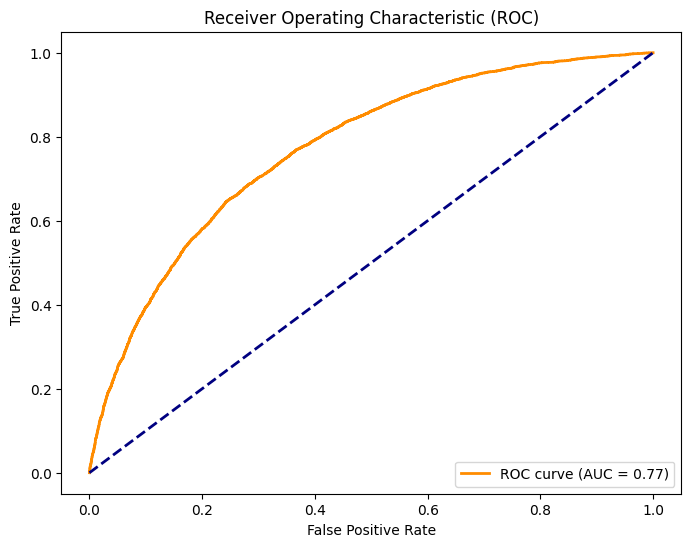

In [57]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [58]:
#Save model data
torch.save(model.state_dict(), 'final_chess_model-2017-05.pth')